# Tracking aspherical particles from 2D brightfield images

In [1]:
# To do
# Check consistency between time the package and time the variable used somewhere.

In [1]:
already_saved = False

# Importations

In [73]:
import numpy as np
import pandas as pd

import pims
import trackpy as tp

import cv2

from skimage.measure import label, regionprops, find_contours

from tqdm import tqdm
import os
import time 

from scipy.optimize import curve_fit

In [74]:
# import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rc

# change the following to %matplotlib notebook for interactive plotting
%matplotlib inline

# Optionally, tweak styles.
rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.5)
rc('xtick', direction='in', labelsize=10)
rc('ytick', direction='in', labelsize=10)
rc('font', family='serif', size=10)
rc('text', usetex=True)
rc('image', cmap='gray')
rc('figure', dpi=200)
rc('savefig', dpi=200)

In [75]:
import sys
sys.path.append("/home/nfares/postdoc/experiments/tracking/utilities/")

import plots

In [76]:
# os.environ["OMP_NUM_THREADS"] = "30"
# os.environ["MKL_NUM_THREADS"] = "30"

# Auxiliary functions

In [77]:
# import ring_tracking
from ring_tracking import locate_ring

from inner_part_tracking import locate_inner_part

from PIL import Image

In [78]:
# Track the shell

img = np.array(Image.open("./im_62.png").convert("L"))

ring_result = locate_ring(img)

print("Ring localization result:")
for k, v in ring_result.items():
    if k in ("r_profile", "profile"):
        continue
    print(f"  {k}: {v:.3f}" if isinstance(v, (int, float)) else f"  {k}: {v}")

Ring localization result:
  center_x: 227.096
  center_y: 207.166
  radius: 23.023
  sigma: 3.091
  intensity_peak: 56.074
  intensity_integrated: 62851.567
  baseline: 49.614
  valid: 1.000
  method: 2d_fit


In [79]:
# Track the core 

inner_result = locate_inner_part(img, ring_result)
 
print("Inner part result:")
for k, v in inner_result.items():
    if k == "mask":
        continue
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Inner part result:
  area: 756
  center_x: 224.783
  center_y: 204.957
  intensity_integrated: 70305.000
  intensity_mean: 138.996
  threshold: 26.687
  bg_mean: 46.000
  bg_std: 8.896
  r_boundary: 17.500
  edge_effect: False


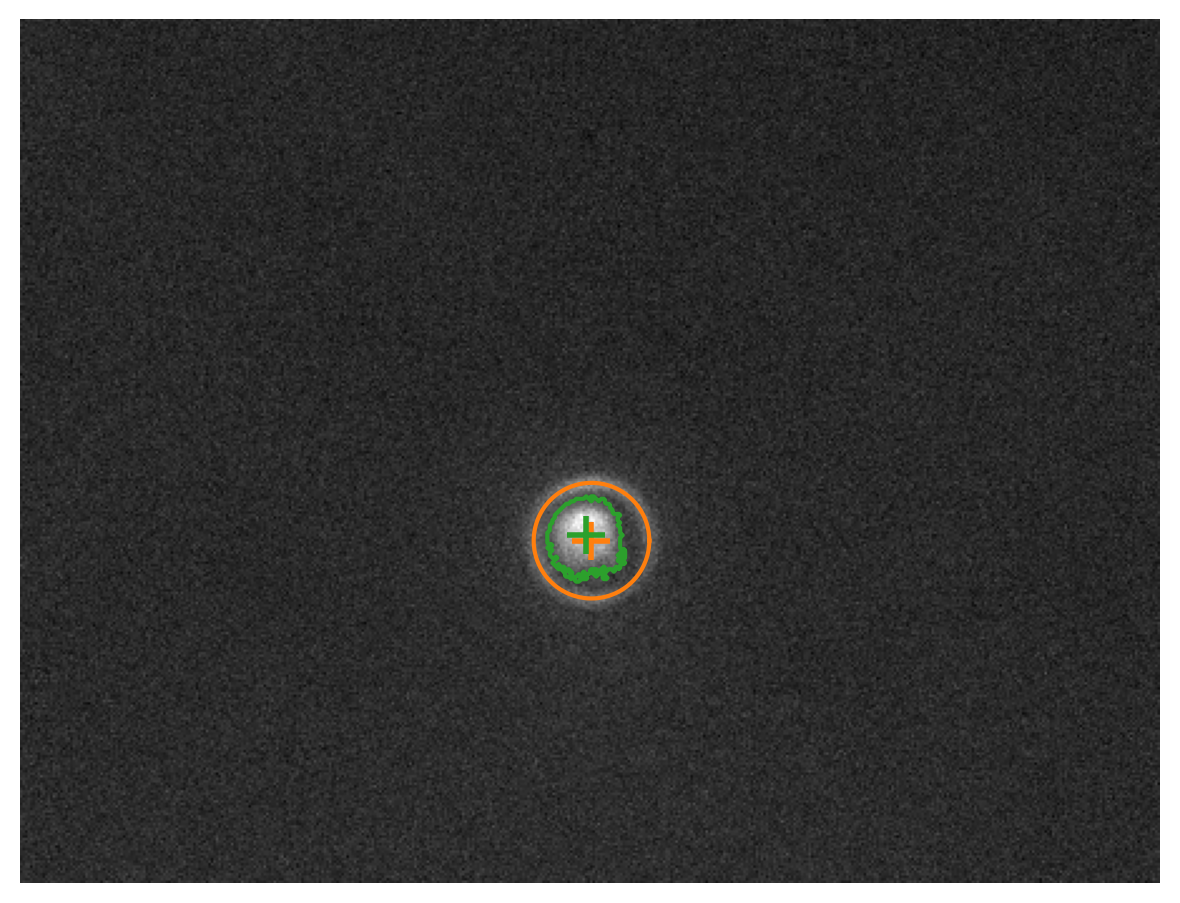

In [80]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap='gray')

# --- Shell: Center + ring ---
# center
ax.plot(ring_result['center_x'], ring_result['center_y'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
# Ring
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(ring_result['center_x'] + ring_result['radius'] * np.cos(theta),
        ring_result['center_y'] + ring_result['radius'] * np.sin(theta),
        '-', c='tab:orange', linewidth=1.5, label='ring fit')

# --- inner part: mask outline + center of mass ---
mask = inner_result['mask']
ax.contour(mask, levels=[0.5], colors='tab:green', linewidths=1.5)
ax.plot(inner_result['center_x'], inner_result['center_y'], '+', mec='tab:green', 
        markersize=14, markeredgewidth=2, label='inner COM')


# ax.set_title(f"center=({res['center_x']:.1f}, {res['center_y']:.1f})  "
#              f"r={res['radius']:.1f}px  I={res['intensity_peak']:.1f}")
# ax.legend(loc='upper right', fontsize=8)

ax.axis('off')

plt.tight_layout()
plt.show()

In [81]:
# from particle_localization import localize_particle

# result = localize_particle(img)

# if result is None:
#     print("No particle found")
# else:
#     print(f"center: ({result['center_x']:.1f}, {result['center_y']:.1f})")
#     print(f"area: {result['area']} px")
#     print(f"equivalent radius: {result['equiv_radius']:.1f} px")

In [82]:
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(img, cmap='gray')

# if result is not None:
#     ax.contour(result['mask'], levels=[0.5], colors='yellow', linewidths=1.5)
#     ax.plot(result['center_x'], result['center_y'], '+', mec='red',
#             markersize=14, markeredgewidth=2, label='center')
#     ax.set_title(f"center=({result['center_x']:.1f}, {result['center_y']:.1f})  "
#                  f"r_eq={result['equiv_radius']:.1f}px")
#     ax.legend(loc='upper right', fontsize=8)

# ax.axis('off')
# plt.tight_layout()
# # plt.savefig('snippet_plot_result.png', dpi=130)
# plt.show()

In [83]:
# from ring_tracker import track_ring

In [12]:
# res = track_ring(img, 131, 70, 28)

In [13]:
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(img, cmap='gray')

# # --- Shell: Center + ring ---
# # center
# ax.plot(res['cx'], res['cy'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
# # # Ring
# # theta = np.linspace(0, 2 * np.pi, 200)
# # ax.plot(ring_result['center_x'] + ring_result['radius'] * np.cos(theta),
# #         ring_result['center_y'] + ring_result['radius'] * np.sin(theta),
# #         '-', c='tab:orange', linewidth=1.5, label='ring fit')

# plt.tight_layout()
# plt.show()

# Inputs

In [85]:
# Where to find the data
path2vid = '/home/nfares/postdoc/experiments/data/Rattler/20260908_rattler_diffusing_withPEG_DIC/ole017_fps_50_p6.tif'

# Frame rate
fps = 50

# Pixel size (in m)
px = 40e-9

# Get the frames 

In [86]:
import re
from pathlib import Path
import tifffile

In [87]:
# ----------------------------------------------------------------------
# A) single multi-page TIFF
# ----------------------------------------------------------------------

def load_multipage_tiff(path):
    """
    Load a multi-page TIFF into a 3D array (n_frames, height, width).
    Works for a single-page tiff too (returns n_frames=1).axes[1].imshow(binary, cmap='gray');  axes[1].set_title('Binary')

    """
    stack = tifffile.imread(path)  # shape (N, H, W) if multi-page, (H, W) if single
    if stack.ndim == 2:
        stack = stack[np.newaxis, ...]
    return stack  # index frames as stack[i]

In [88]:
# ----------------------------------------------------------------------
# B) folder of individual TIFF files (one frame per file)
# ----------------------------------------------------------------------
def _natural_key(path):
    """Sort 'frame2.tif' before 'frame10.tif' (plain sort would do the opposite)."""
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", path.stem)]
 
 
def load_tiff_stack_folder(folder, pattern="*.tif*"):
    """
    Load every TIFF file in a folder, sorted in natural frame order, into a
    list of 2D arrays. Use a list (not a forced np.stack) in case frame
    sizes ever differ; stack yourself with np.stack(frames) if they're all
    the same shape and you want a single 3D array.
    """
    paths = sorted(Path(folder).glob(pattern), key=_natural_key)
    if not paths:
        raise FileNotFoundError(f"No TIFF files found in {folder} matching {pattern}")
    frames = [tifffile.imread(p) for p in paths]
    return frames, paths  # paths returned too, useful for logging/debugging

In [89]:


stack = load_multipage_tiff(path2vid)



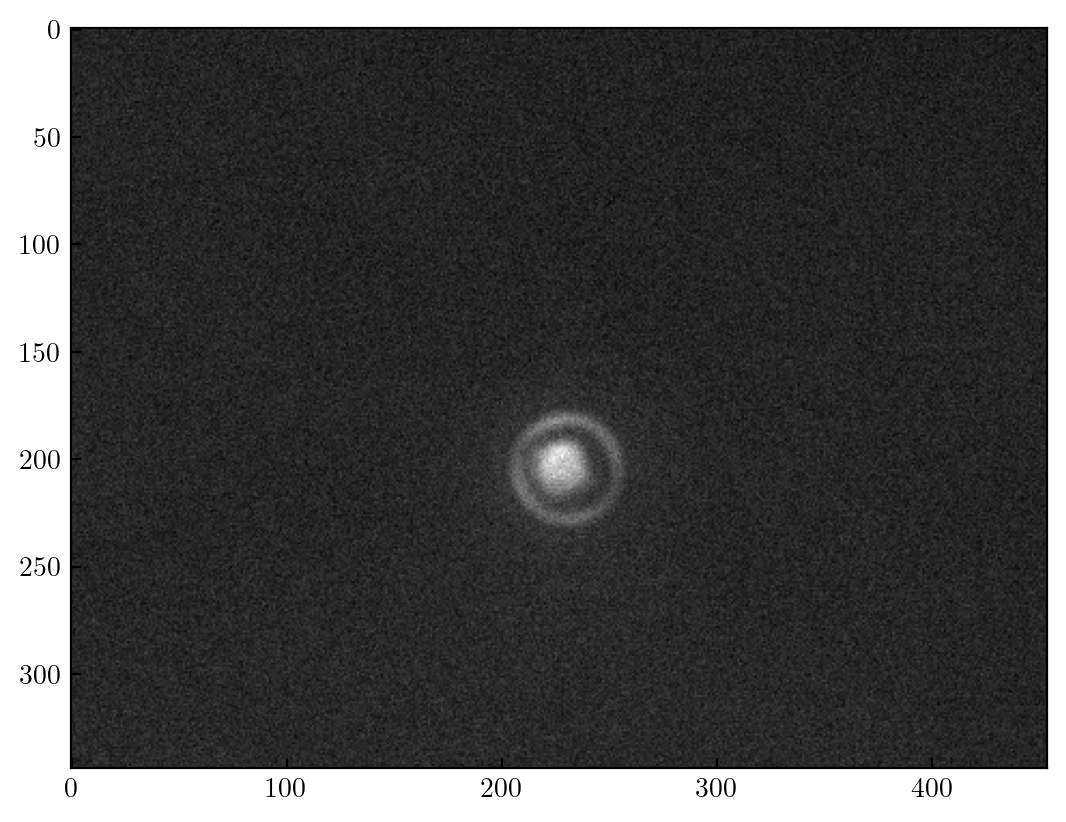

In [90]:
i = 80
plt.imshow(stack[i])

In [91]:
# for i in range(0, 3, 1):
#     plt.imsave('im_' +str(i)+'.png', stack[i])

In [92]:
# plt.imsave('im_' +str(i)+'.png', stack[i])

In [93]:
# Nim = 100 #len(stack)

start = 0
stop = 50
step = 1

Nim = (stop - start) // step

xsize, ysize = stack[0].shape[::-1]

print(Nim)

50


In [94]:
# # background 

# start_bg = 0 
# stop_bg = Nim
# Nim_bg = 20

# set_images = np.arange(start_bg, stop_bg, (stop_bg - start_bg) // Nim_bg)

# images = []

# for i in tqdm(range(len(set_images))):
#     index = set_images[i]
#     images.append(stack[index])

# bg = np.median(images, axis=0)
# bg[bg == 0] = 1

# del images

In [95]:
# plt.imshow(bg)

In [96]:
def to_uint8(frame, vmin=None, vmax=None):
    frame = frame.astype(np.float64)
    if vmin is None:
        vmin = frame.min()
    if vmax is None:
        vmax = frame.max()
    scaled = (frame - vmin) / (vmax - vmin) * 255
    return np.clip(scaled, 0, 255).astype(np.uint8)

In [97]:
xouter = np.zeros(Nim)
youter = np.zeros(Nim)
Router = np.zeros(Nim)
Souter = np.zeros(Nim)
xinner = np.zeros(Nim)
yinner = np.zeros(Nim)

for i in tqdm(range(start, stop, step)): #, frame in enumerate(stack):

    frame = stack[i]

    j = i - start

    # frame = ((frame.astype(float) - frame.min()) / (frame.max() - frame.min()) * 255).astype(np.uint8)
    # frame = to_uint8(frame)
    
    outer_result = locate_ring(frame, min_snr=3, smoothing_sigma=3.)
    inner_result = locate_inner_part(frame, outer_result)

    xouter[j] = outer_result['center_x']
    youter[j] = ysize - outer_result['center_y']
    Router[j] = outer_result['radius']
    Souter[j] = outer_result['sigma']
    xinner[j] = inner_result['center_x']
    yinner[j] = ysize - inner_result['center_y']
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.imshow(frame, cmap='gray')
    
    # --- Shell: Center + ring ---
    # center
    ax.plot(outer_result['center_x'], outer_result['center_y'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
    # Ring
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(outer_result['center_x'] + outer_result['radius'] * np.cos(theta),
            outer_result['center_y'] + outer_result['radius'] * np.sin(theta),
            '-', c='tab:orange', linewidth=1.5, label='ring fit')
    
    # --- inner part: mask outline + center of mass ---
    mask = inner_result['mask']
    ax.contour(mask, levels=[0.5], colors='tab:green', linewidths=1.5)
    ax.plot(inner_result['center_x'], inner_result['center_y'], '+', mec='tab:green', 
            markersize=14, markeredgewidth=2, label='inner COM')
    
    ax.axis('off')
    
    plt.tight_layout()

    fig.savefig('./temp/image_' + str(i) + '.png')

    plt.close(fig)
    # plt.show()

100%|█████████████████████████████████████████████████████████████████████████| 50/50 [00:32<00:00,  1.55it/s]


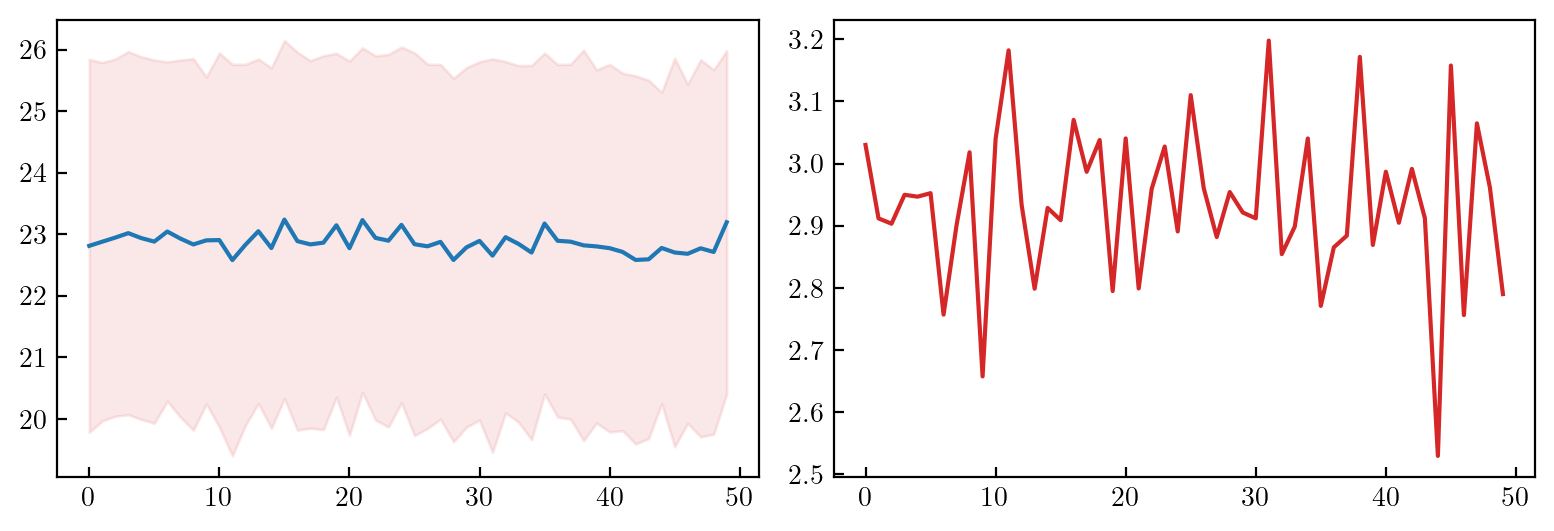

In [98]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(20/2.54, 7/2.54))

cond = Router > 0

ax1.plot(np.arange(len(Router[cond])), Router[cond], ls='-', c='tab:blue')
ax1.fill_between(np.arange(len(Router[cond])), Router[cond] - Souter[cond], Router[cond]+Souter[cond], color='tab:red', alpha=0.1)

ax2.plot(Souter[cond], ls='-', c='tab:red')

plt.tight_layout()
plt.show()

In [28]:
# fig.savefig('radii_without_uint8_conversion.pdf')

In [29]:
np.std(Router[:])

np.float64(0.2109329665379539)

In [30]:
Rr = np.nanmean(Router)
Sr = np.nanmean(Souter)
print(Rr, Sr)

std_Rr = np.nanstd(Router)
std_Sr = np.nanstd(Souter)

# maybe 2D histogram to choose... Not necessary a priori

23.866487492337193 3.006642676203841


In [31]:
i = 303
# plt.imshow(stack[i])

# plt.imsave('im_' +str(i)+'.png', stack[i])

# tifffile.imwrite('frame_{}.tif'.format(i), stack[i])

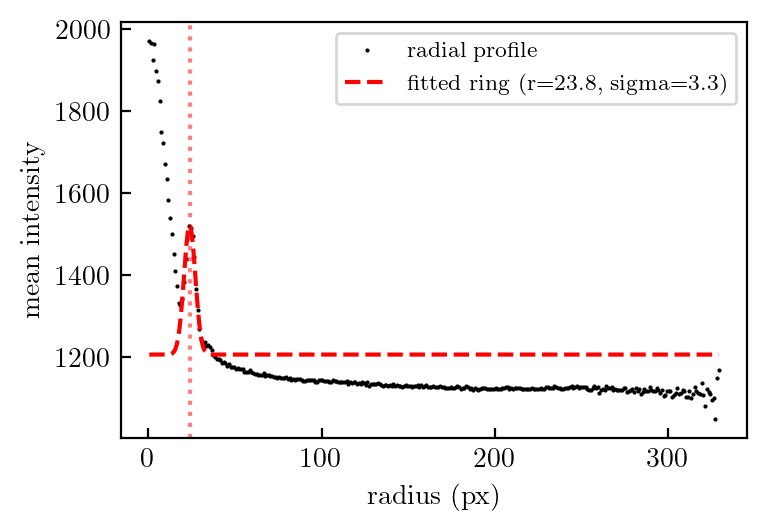

In [32]:
from ring_tracking import plot_radial_profile

i = 87

frame = stack[i]
    
outer_result = locate_ring(frame, min_snr=3, smoothing_sigma=3.)

fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

r, profile, fig = plot_radial_profile(frame, result=outer_result, save_path='profile.png', fig=fig, ax=ax)

In [44]:
start = 0
stop = 500
step = 1

Nim = (stop - start) // step

print(Nim)

500


In [46]:
xouter = np.zeros(Nim)
youter = np.zeros(Nim)
Router = np.zeros(Nim)
Souter = np.zeros(Nim)
xinner = np.zeros(Nim)
yinner = np.zeros(Nim)

for i in tqdm(range(start, stop, step)): #, frame in enumerate(stack):

    frame = stack[i]

    j = i - start # to match array indexing starting at 0

    # print(i)

    # frame = ((frame.astype(float) - frame.min()) / (frame.max() - frame.min()) * 255).astype(np.uint8)
    # frame = to_uint8(frame)
    
    outer_result = locate_ring(frame, min_snr=3, smoothing_sigma=3., fixed_params={"a": Rr, "sigma": Sr})
    inner_result = locate_inner_part(frame, outer_result)

    # if i == 302:
    #     print(inner_result)

    xouter[j] = outer_result['center_x']
    youter[j] = ysize - outer_result['center_y']
    Router[j] = outer_result['radius']
    Souter[j] = outer_result['sigma']
    xinner[j] = inner_result['center_x']
    yinner[j] = ysize - inner_result['center_y']
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.imshow(frame, cmap='gray')
    
    # --- Shell: Center + ring ---
    # center
    ax.plot(outer_result['center_x'], outer_result['center_y'], '+', mec='tab:orange', markersize=14, markeredgewidth=2, label='center')
    # Ring
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(outer_result['center_x'] + outer_result['radius'] * np.cos(theta),
            outer_result['center_y'] + outer_result['radius'] * np.sin(theta),
            '-', c='tab:orange', linewidth=1.5, label='ring fit')
    
    # --- inner part: mask outline + center of mass ---
    mask = inner_result['mask']
    ax.contour(mask, levels=[0.5], colors='tab:green', linewidths=1.5)
    ax.plot(inner_result['center_x'], inner_result['center_y'], '+', mec='tab:green', 
            markersize=14, markeredgewidth=2, label='inner COM')
    
    ax.axis('off')
    
    plt.tight_layout()

    fig.savefig('./temp/image_' + str(i) + '.png')

    plt.close(fig)
    # plt.show()

100%|███████████████████████████████████████████████████████████████████████| 500/500 [02:01<00:00,  4.10it/s]


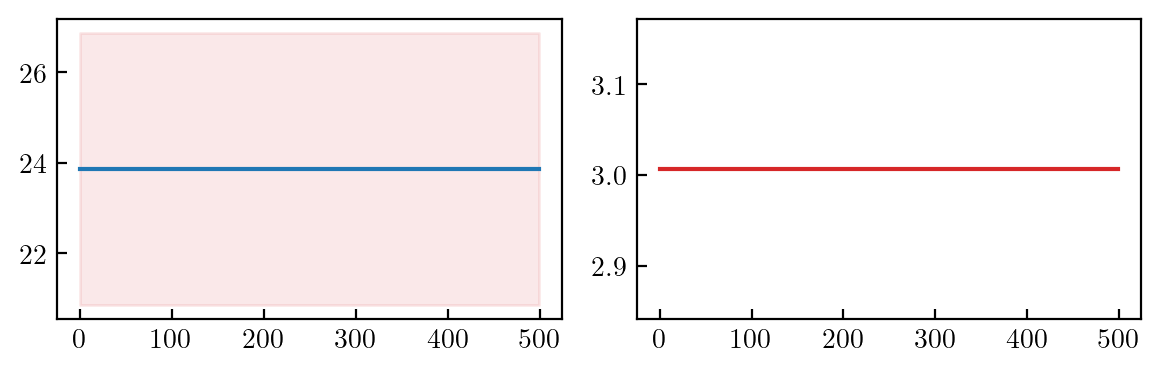

In [47]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15/2.54, 5/2.54))

cond = Router > 0

ax1.plot(np.arange(len(Router[cond])), Router[cond], ls='-', c='tab:blue')
ax1.fill_between(np.arange(len(Router[cond])), Router[cond] - Souter[cond], Router[cond]+Souter[cond], color='tab:red', alpha=0.1)

ax2.plot(Souter[cond], ls='-', c='tab:red')

plt.tight_layout()
plt.show()

In [48]:
from ring_tracking import plot_radial_profile

i = 303

frame = stack[i]
    
outer_result = locate_ring(frame, min_snr=3, smoothing_sigma=3.)

# fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

# r, profile, fig = plot_radial_profile(frame, result=outer_result, save_path='profile.png', fig=fig, ax=ax)

In [49]:
ring_result = locate_ring(frame)
print("valid:", ring_result['valid'])
# print(ring_result)

valid: True


In [50]:
from diagnose_inner_none import diagnose_inner_part
diagnose_inner_part(frame, outer_result)

ring_result['valid']: True
xc=203.07870566045514, yc=95.32368638582871, r_ring=23.731234695612258
bg_mean=1174.0, bg_std=51.891, edge_effect=False
offset=155.673
r_boundary=17.5
threshold=155.673, mask sum=804
No failure found -- locate_inner_part should succeed. If it's still returning None for you, something differs between this diagnostic and your actual call (e.g. different img, different ring_result, or different keyword arguments to locate_inner_part).


In [51]:
outer_result = locate_ring(frame)

from diagnose_inner_none import diagnose_inner_part
diagnose_inner_part(frame, outer_result)   # <-- add this line right here

inner_result = locate_inner_part(frame, outer_result) 

ring_result['valid']: True
xc=202.57721607100413, yc=94.94565287117933, r_ring=23.555695783128154
bg_mean=1175.0, bg_std=51.891, edge_effect=False
offset=155.673
r_boundary=17.5
threshold=155.673, mask sum=794
No failure found -- locate_inner_part should succeed. If it's still returning None for you, something differs between this diagnostic and your actual call (e.g. different img, different ring_result, or different keyword arguments to locate_inner_part).


In [52]:
inner_result

{'area': 794,
 'center_x': np.float64(203.2816282342752),
 'center_y': np.float64(96.91198170401645),
 'intensity_integrated': np.float64(369480.0),
 'intensity_mean': np.float64(1640.3400503778337),
 'threshold': np.float64(155.673),
 'bg_mean': np.float64(1175.0),
 'bg_std': np.float64(51.891),
 'r_boundary': np.float64(17.5),
 'mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(328, 426)),
 'edge_effect': np.False_}

# Quick analysis

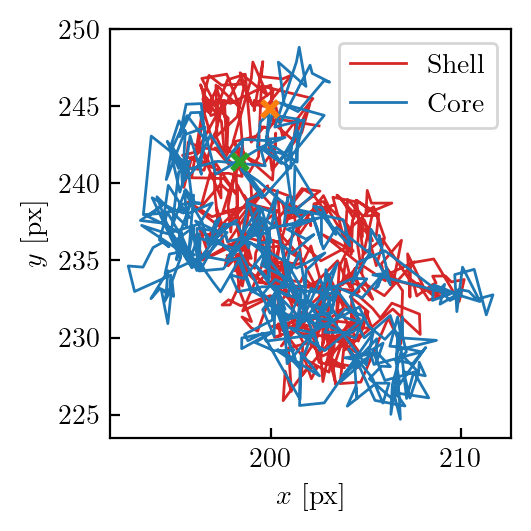

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(7/2.54, 7/2.54))

start = 0
stop = -1
step = 1

ax.plot(xouter[start:stop:step], youter[start:stop:step], ls='-', lw=1, c='tab:red', label='Shell')
ax.plot(xinner[start:stop:step], yinner[start:stop:step], ls='-', lw=1, c='tab:blue', label='Core')

ax.plot(xouter[start], youter[start], ls='', marker='x', mec='tab:orange', ms=6, mew=2)
ax.plot(xinner[start], yinner[start], ls='', marker='x', mec='tab:green', ms=6, mew=2)

ax.legend()
ax.set(xlabel=r'$x$ [px]', ylabel=r'$y$ [px]')

plt.tight_layout()
plt.show()

In [54]:
# xouter

In [55]:
def moment(n, x, t, return_std = False, retrieve_mean = False, mean_abs = False):
    """
    Parameters
    ----------
    n: int, moment of order n
    x: array containing the values of interest
    t: an array containing differences of indexes.
    """
    res = np.zeros(len(t))
    std = np.zeros(len(t))
    for i, j in enumerate(t):
        #x_tau = x[j:] - np.mean(x[j:])
        #x_zer = x[0:-j] - np.mean(x[0:-j])
        #res[i] = np.nanmean((x_tau - x_zer)**n)
        Delta_x = x[j:] - x[0:-j]
        if retrieve_mean:
            distribution = (Delta_x - np.mean(Delta_x)) ** n
        else:
            distribution = (Delta_x) ** n
        if mean_abs:
            distribution = np.abs(distribution)
        res[i] = np.nanmean(distribution)
        std[i] = np.nanstd(distribution)
    if return_std:
        return res, std
    else:
        return res

In [60]:
dframes = np.concatenate((np.arange(1, 10, 1), np.arange(10, 100, 2), np.arange(100, 500, 5)))

msdxouter = moment(2, xouter, dframes, retrieve_mean=False)
msdyouter = moment(2, youter, dframes, retrieve_mean=False)
msdxinner = moment(2, xinner, dframes, retrieve_mean=False)
msdyinner = moment(2, yinner, dframes, retrieve_mean=False)

msdouter = (msdxouter + msdyouter) / 2
msdinner = (msdxinner + msdyinner) / 2

msdxboth = moment(2, xinner-xouter, dframes, retrieve_mean=False)
msdyboth = moment(2, yinner-youter, dframes, retrieve_mean=False)

msdboth = (msdxboth + msdyboth) / 2

dtimes = dframes / fps

In [61]:
fps

50

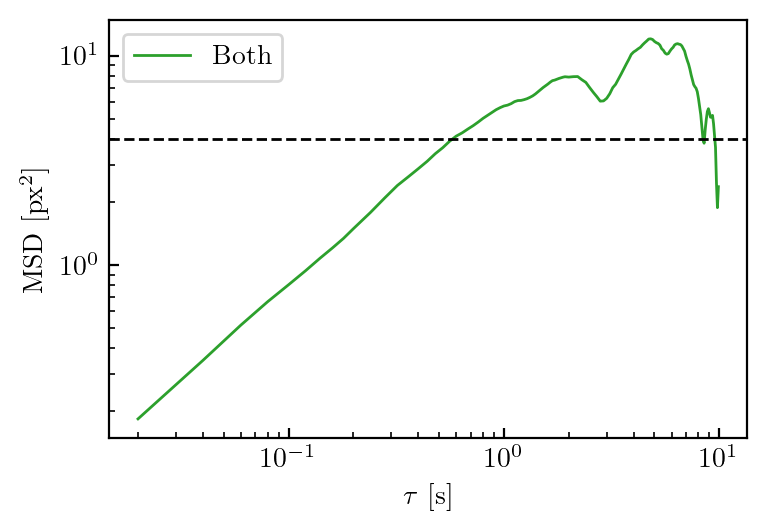

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

# ax.plot(dtimes, msdouter, ls='-', lw=1, c='tab:red', label='Shell')
# # ax.plot(dtimes, msdouter, ls='', marker='o', c='tab:red', label='Shell')
# ax.plot(dtimes, msdinner, ls='-', lw=1, c='tab:blue', label='Core')
ax.plot(dtimes, msdboth, ls='-', lw=1, c='tab:green', label='Both')

# ax.plot(dtimes[2:-2], 100 * dtimes[2:-2], ls='--', c='k')

ax.axhline(y=(2*1)**2, ls='--', c='k', lw=1)

ax.legend()
ax.set(xlabel=r'$\tau$ [s]', ylabel=r'MSD [$\mathrm{px^2}$]', xscale='log', yscale='log')

plt.tight_layout()
plt.show()

In [110]:
np.sqrt(6)/2 * px * 1e9

np.float64(48.989794855663554)

In [63]:
# ── Wiener-Khinchin (via autocorrelation) ──────────────────────────────
def autocorrelation_biased(a):
    a = a - np.mean(a)
    N = len(a)
    f = np.fft.rfft(a, n=2*N)
    acf = np.fft.irfft(f * np.conj(f))[:N]
    acf /= N  # divide by N instead of N-lag
    return acf
    
def compute_psd(a, dt):
    x_detrended = a #signal.detrend(a, type='linear')
    acf = autocorrelation_biased(x_detrended)
    psd_wk = np.fft.rfft(acf) * dt
    freqs_wk = np.fft.rfftfreq(len(acf), d=dt)
    return freqs_wk, psd_wk

In [64]:
freqs_outer, psd_xouter = compute_psd(xouter, dt=1/fps)
_, psd_youter = compute_psd(youter, dt=1/fps)

freqs_inner, psd_xinner = compute_psd(xinner, dt=1/fps)
_, psd_yinner = compute_psd(yinner, dt=1/fps)

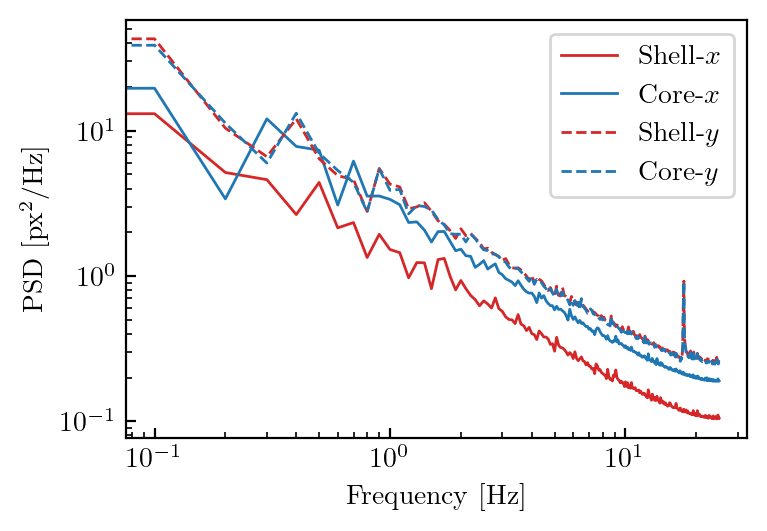

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot(freqs_outer, np.abs(psd_xouter), ls='-', lw=1, c='tab:red', label='Shell-$x$')
ax.plot(freqs_inner, np.abs(psd_xinner), ls='-', lw=1, c='tab:blue', label='Core-$x$')

ax.plot(freqs_outer, np.abs(psd_youter), ls='--', lw=1, c='tab:red', label='Shell-$y$')
ax.plot(freqs_inner, np.abs(psd_yinner), ls='--', lw=1, c='tab:blue', label='Core-$y$')

ax.legend()
ax.set(xlabel='Frequency [Hz]', ylabel=r'PSD [$\mathrm{px^2/Hz}$]', xscale='log', yscale='log')

# plt.ylim([1e-22, None])

plt.tight_layout()
plt.show()

In [66]:
def crosscorrelation_biased(a, b, dt):
    
    assert len(a) == len(b)
    
    a = a - np.mean(a)
    b = b - np.mean(b)
    N = len(a)

    fa = np.fft.rfft(a, n=2*N)
    fb = np.fft.rfft(b, n=2*N)

    # # cross-power spectrum: conj(fa) * fb gives corr(a,b) with b shifted forward
    # ccf = np.fft.irfft(np.conj(fa) * fb, n=2*N)
    # ccf /= N  # biased normalization, same convention as your acf

    # # reorder: irfft gives [lag 0, 1, ..., N-1, -(N), ..., -1]
    # # rearrange to [-(N-1), ..., -1, 0, 1, ..., N-1]
    # ccf = np.concatenate((ccf[-(N-1):], ccf[:N]))

    # lags = np.arange(-(N-1), N)
    # lags = lags * dt

    # cross-power spectrum: conj(fa) * fb gives corr(a,b) with b shifted forward
    ccf = np.fft.irfft(np.conj(fa) * fb, n=2*N)[:N]
    ccf /= N  # biased normalization, same convention as your acf

    lags = np.arange(0, N)
    lags = lags * dt
    
    return lags, ccf

In [67]:
lags_x, ccf_x = crosscorrelation_biased(xouter, xinner, dt=1/fps)
lags_y, ccf_y = crosscorrelation_biased(youter, yinner, dt=1/fps)

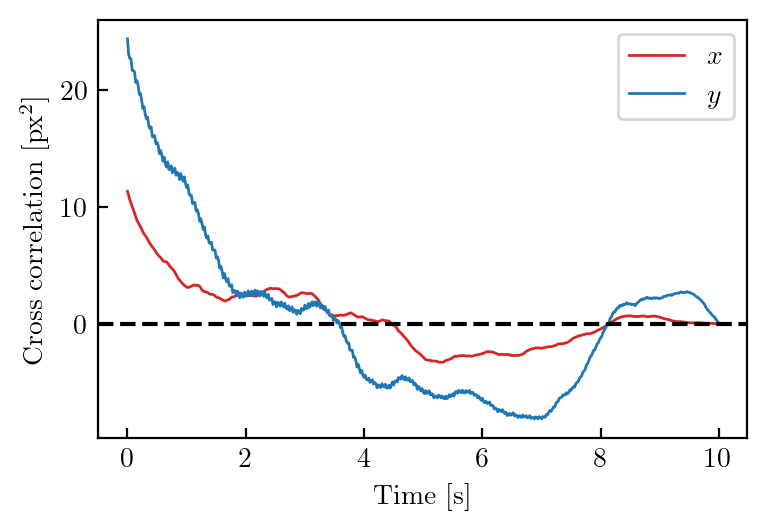

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot(lags_x, ccf_x, ls='-', lw=1, c='tab:red', label='$x$')
ax.plot(lags_y, ccf_y, ls='-', lw=1, c='tab:blue', label='$y$')

ax.axhline(y=0, ls='--', c='k')

ax.legend()
ax.set(xlabel='Time [s]', ylabel=r'Cross correlation [$\mathrm{px^2}$]', xscale='linear', yscale='linear')

plt.tight_layout()
plt.show()

In [69]:
def pdf(data, bins=10, density=True, range=None):
    pdf, bins_edge = np.histogram(
        data, 
        bins=bins, 
        density=density, 
        range=range, 
    )
    bins_center = (bins_edge[0:-1] + bins_edge[1:]) / 2
    return pdf, bins_center

In [70]:
rr = np.sqrt((xinner - xouter) ** 2 + (yinner - youter) ** 2)

# rr = rr[:100]

In [71]:
Pr, bins_Pr = pdf(rr, bins=30, range=None)

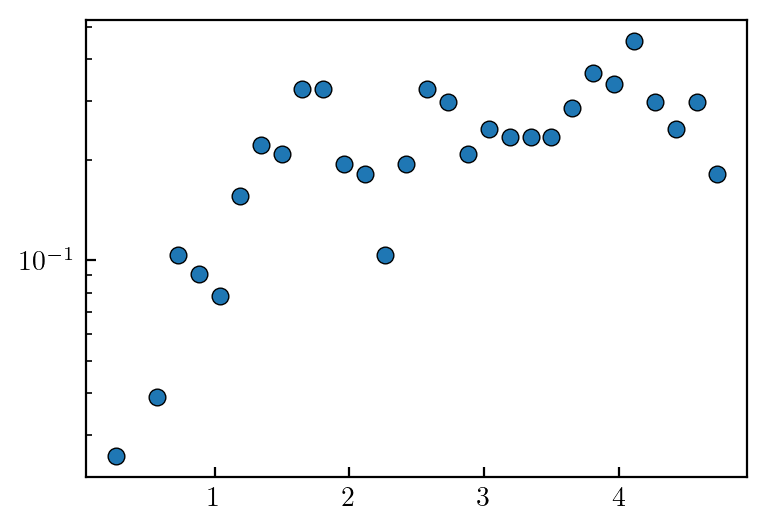

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(10/2.54, 7/2.54))

ax.plot(bins_Pr, Pr, ls='', marker='o')

ax.set(yscale='log')

plt.tight_layout()
plt.show()